In [1]:
!pip install opendatasets

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import pandas as pd

# Read the synthetic salary dataset (upload salary_dataset.csv to Colab and adjust the path if needed)
df = pd.read_csv('/content/salary_dataset.csv')

# Print the first 5 rows of the DataFrame
print(df.head())


   EmployeeID  Age EducationLevel  ExperienceYears   Department       City  \
0           1   59            PhD               28           HR  Bangalore   
1           2   49            PhD               25      Finance      Delhi   
2           3   35        Masters               34      Finance     Mumbai   
3           4   28            PhD               24    Marketing      Delhi   
4           5   41        Masters               23  Engineering      Delhi   

   Gender  Salary  
0    Male  130904  
1    Male   96534  
2    Male   75106  
3    Male  132599  
4  Female   50678  


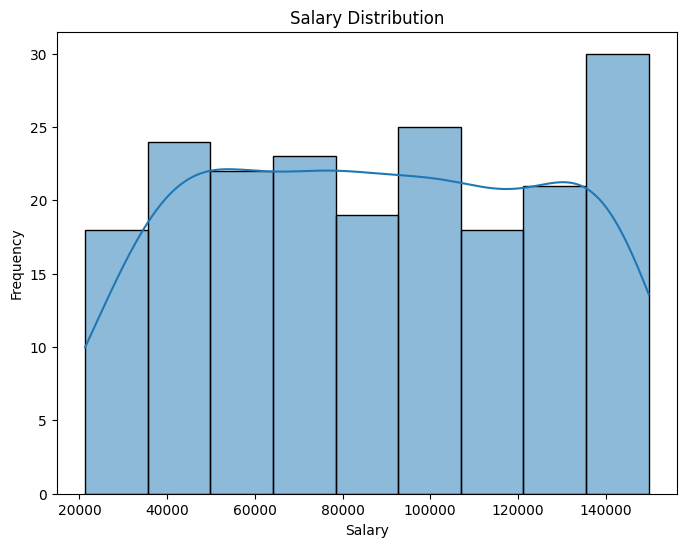

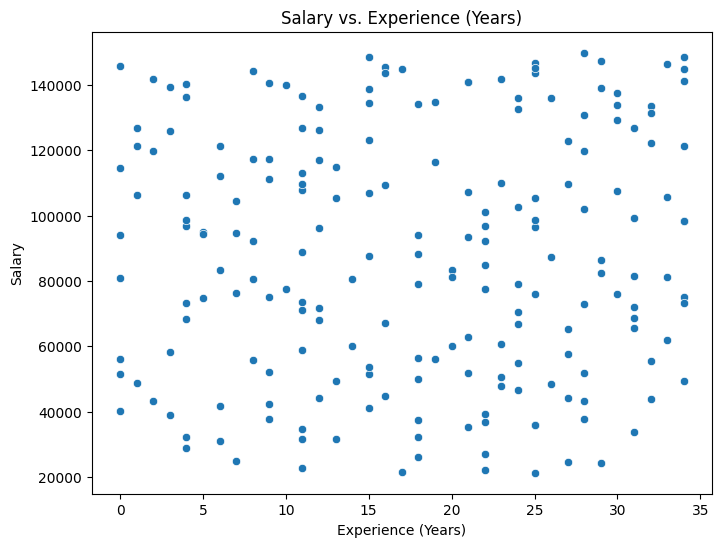

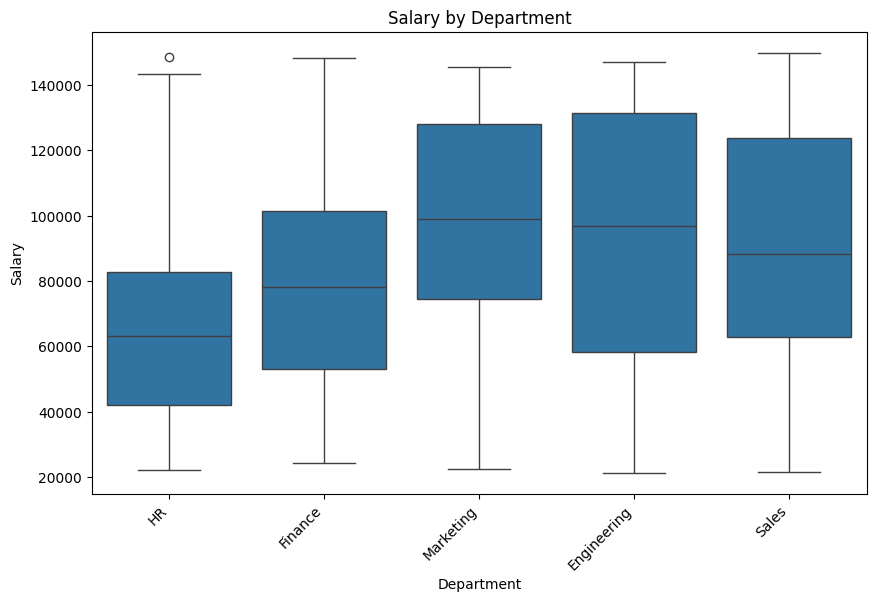

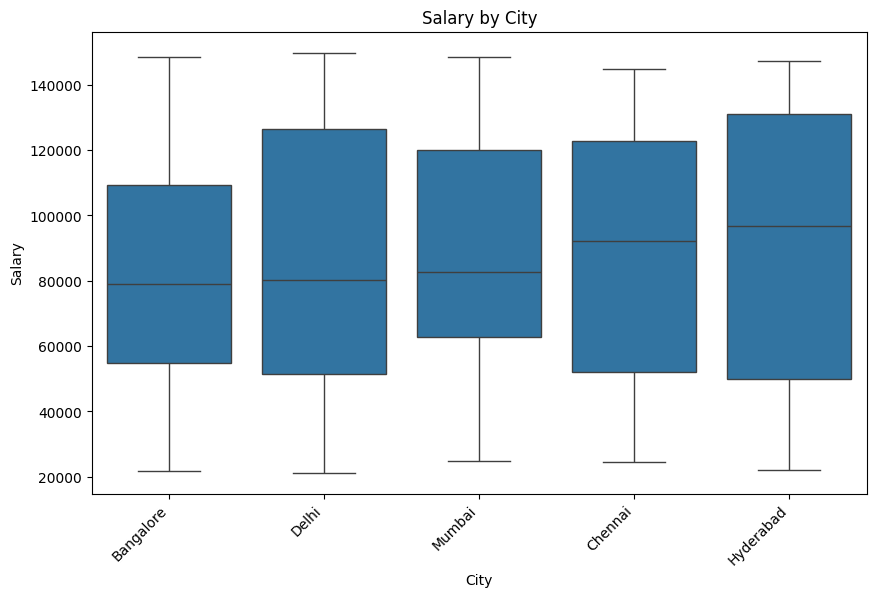

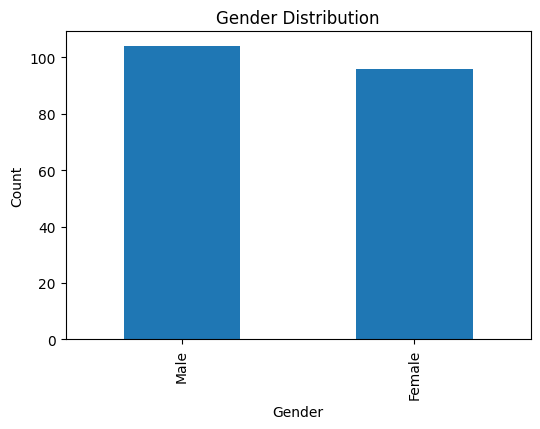

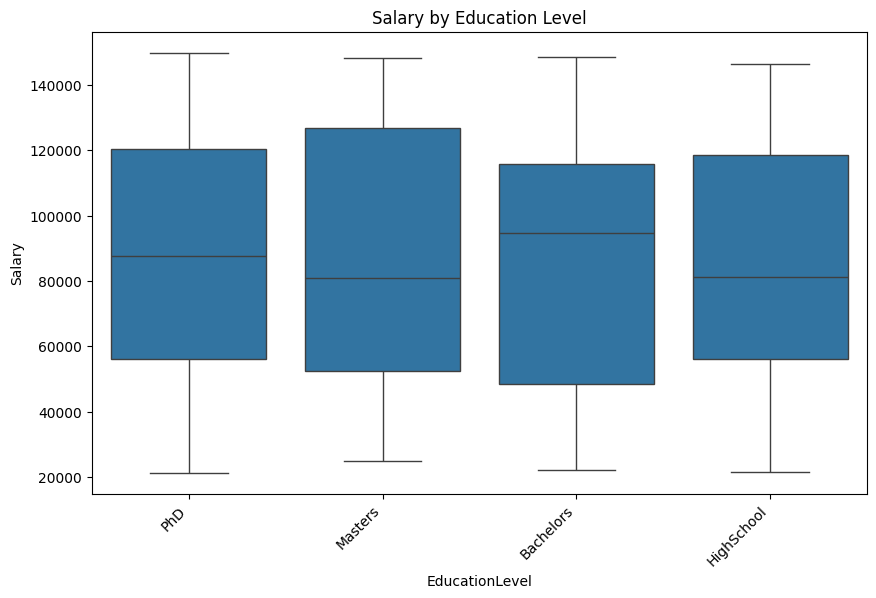

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizations on the salary dataset

# 1. Salary Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Salary'], kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

# 2. Salary vs. ExperienceYears
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ExperienceYears', y='Salary', data=df)
plt.title('Salary vs. Experience (Years)')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.show()

# 3. Salary by Department
plt.figure(figsize=(10, 6))
sns.boxplot(x='Department', y='Salary', data=df)
plt.title('Salary by Department')
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Salary by City
plt.figure(figsize=(10, 6))
sns.boxplot(x='City', y='Salary', data=df)
plt.title('Salary by City')
plt.xticks(rotation=45, ha='right')
plt.show()

# 5. Gender Distribution
plt.figure(figsize=(6, 4))
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# 6. Education Level vs. Salary
plt.figure(figsize=(10, 6))
sns.boxplot(x='EducationLevel', y='Salary', data=df)
plt.title('Salary by Education Level')
plt.xticks(rotation=45, ha='right')
plt.show()


In [5]:
import pandas as pd

data = df.copy()  # Creating a copy to avoid modifying the original DataFrame

# Binarization of 'City'
data_city = pd.get_dummies(data, columns=['City'], prefix='City', drop_first=True)
print("After binarizing 'City':")
print(data_city.head())


After binarizing 'City':
   EmployeeID  Age EducationLevel  ExperienceYears   Department  Gender  \
0           1   59            PhD               28           HR    Male   
1           2   49            PhD               25      Finance    Male   
2           3   35        Masters               34      Finance    Male   
3           4   28            PhD               24    Marketing    Male   
4           5   41        Masters               23  Engineering  Female   

   Salary  City_Chennai  City_Delhi  City_Hyderabad  City_Mumbai  
0  130904         False       False           False        False  
1   96534         False        True           False        False  
2   75106         False       False           False         True  
3  132599         False        True           False        False  
4   50678         False        True           False        False  


In [6]:
# Creating 'Male' and 'Female' columns based on 'Gender'
data['Male'] = (data['Gender'] == 'Male').astype(int)
data['Female'] = (data['Gender'] == 'Female').astype(int)

print(data[['Gender', 'Male', 'Female']].head())


   Gender  Male  Female
0    Male     1       0
1    Male     1       0
2    Male     1       0
3    Male     1       0
4  Female     0       1


In [7]:
# Binarization of 'EducationLevel'
data_education = pd.get_dummies(data, columns=['EducationLevel'], prefix='Education', drop_first=True)

print("After binarizing 'EducationLevel':")
print(data_education.head())


After binarizing 'EducationLevel':
   EmployeeID  Age  ExperienceYears   Department       City  Gender  Salary  \
0           1   59               28           HR  Bangalore    Male  130904   
1           2   49               25      Finance      Delhi    Male   96534   
2           3   35               34      Finance     Mumbai    Male   75106   
3           4   28               24    Marketing      Delhi    Male  132599   
4           5   41               23  Engineering      Delhi  Female   50678   

   Male  Female  Education_HighSchool  Education_Masters  Education_PhD  
0     1       0                 False              False           True  
1     1       0                 False              False           True  
2     1       0                 False               True          False  
3     1       0                 False              False           True  
4     0       1                 False               True          False  


In [8]:
# Define thresholds for binarization of ExperienceYears
data['Experience_>=5'] = (data['ExperienceYears'] >= 5).astype(int)
data['Experience_>=10'] = (data['ExperienceYears'] >= 10).astype(int)
data['Experience_>=15'] = (data['ExperienceYears'] >= 15).astype(int)
data['Experience_>=20'] = (data['ExperienceYears'] >= 20).astype(int)

# Display the updated DataFrame
print("Binarized 'ExperienceYears' columns:")
print(data[['ExperienceYears', 'Experience_>=5', 'Experience_>=10', 'Experience_>=15', 'Experience_>=20']].head())


Binarized 'ExperienceYears' columns:
   ExperienceYears  Experience_>=5  Experience_>=10  Experience_>=15  \
0               28               1                1                1   
1               25               1                1                1   
2               34               1                1                1   
3               24               1                1                1   
4               23               1                1                1   

   Experience_>=20  
0                1  
1                1  
2                1  
3                1  
4                1  


In [9]:
# Define the salary threshold (adjust if you like)
salary_threshold = 80000  # mark salaries >= 80k as 'Good'

# Creating the 'Good_Salary' column based on the threshold
data['Good_Salary'] = (data['Salary'] >= salary_threshold).astype(int)

# Creating the 'Bad_Salary' column (opposite of 'Good_Salary')
data['Bad_Salary'] = (data['Salary'] < salary_threshold).astype(int)

# Display the updated DataFrame to verify the new columns
print(data[['Salary', 'Good_Salary', 'Bad_Salary']].head())


   Salary  Good_Salary  Bad_Salary
0  130904            1           0
1   96534            1           0
2   75106            0           1
3  132599            1           0
4   50678            0           1


In [10]:
import pandas as pd

# Make sure there are no leading/trailing spaces in column names
data.columns = data.columns.str.strip()

# One-hot encode City, EducationLevel, and Department
data_city = pd.get_dummies(data, columns=['City'], prefix='City', drop_first=True)
data_education = pd.get_dummies(data_city, columns=['EducationLevel'], prefix='Education', drop_first=True)
data_full = pd.get_dummies(data_education, columns=['Department'], prefix='Dept', drop_first=True)

# Columns we want to keep that are already binary or numeric thresholds
columns_to_keep = [
    'Male', 'Female',
    'Experience_>=5', 'Experience_>=10', 'Experience_>=15', 'Experience_>=20',
    'Good_Salary', 'Bad_Salary'
]

# Select all dummy columns (City, Education, Dept) plus the binary/threshold columns
dummy_cols = [col for col in data_full.columns
              if col.startswith('City_') or col.startswith('Education_') or col.startswith('Dept_')]

final_cols = dummy_cols + columns_to_keep

final_data = data_full[final_cols].copy()

print("Merged binary DataFrame (formal context-style):")
print(final_data.head())


Merged binary DataFrame (formal context-style):
   City_Chennai  City_Delhi  City_Hyderabad  City_Mumbai  \
0         False       False           False        False   
1         False        True           False        False   
2         False       False           False         True   
3         False        True           False        False   
4         False        True           False        False   

   Education_HighSchool  Education_Masters  Education_PhD  Dept_Finance  \
0                 False              False           True         False   
1                 False              False           True          True   
2                 False               True          False          True   
3                 False              False           True         False   
4                 False               True          False         False   

   Dept_HR  Dept_Marketing  Dept_Sales  Male  Female  Experience_>=5  \
0     True           False       False     1       0               1

In [11]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   City_Chennai          200 non-null    bool 
 1   City_Delhi            200 non-null    bool 
 2   City_Hyderabad        200 non-null    bool 
 3   City_Mumbai           200 non-null    bool 
 4   Education_HighSchool  200 non-null    bool 
 5   Education_Masters     200 non-null    bool 
 6   Education_PhD         200 non-null    bool 
 7   Dept_Finance          200 non-null    bool 
 8   Dept_HR               200 non-null    bool 
 9   Dept_Marketing        200 non-null    bool 
 10  Dept_Sales            200 non-null    bool 
 11  Male                  200 non-null    int64
 12  Female                200 non-null    int64
 13  Experience_>=5        200 non-null    int64
 14  Experience_>=10       200 non-null    int64
 15  Experience_>=15       200 non-null    int64
 16  Experien

In [12]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target variable (y)
X = final_data.drop(['Good_Salary', 'Bad_Salary'], axis=1)
y = final_data['Good_Salary']  # You can choose 'Bad_Salary' as well

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% training and 20% test

# Now I have X_train, X_test, y_train, and y_test for your machine learning models
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(160, 17) (40, 17) (160,) (40,)


In [13]:
formal_context = final_data.copy()

# Replace numerical values with 'x' to represent the presence of an attribute
for col in formal_context.columns:
  formal_context[col] = formal_context[col].apply(lambda x: 'x' if x == 1 else '')

print(formal_context.head())

  City_Chennai City_Delhi City_Hyderabad City_Mumbai Education_HighSchool  \
0                                                                           
1                       x                                                   
2                                                  x                        
3                       x                                                   
4                       x                                                   

  Education_Masters Education_PhD Dept_Finance Dept_HR Dept_Marketing  \
0                               x                    x                  
1                               x            x                          
2                 x                          x                          
3                               x                                   x   
4                 x                                                     

  Dept_Sales Male Female Experience_>=5 Experience_>=10 Experience_>=15  \
0               x      

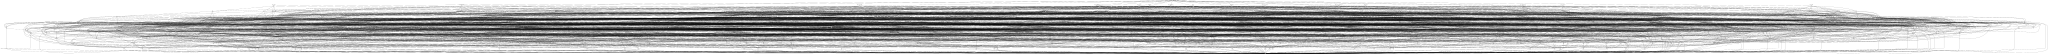

In [14]:
!pip install --upgrade concepts

import pandas as pd
from concepts.lattices import Lattice # Import Lattice from concepts.lattices
from concepts import Context # Import Context as usual
# Converting the DataFrame to a binary context (required for FCA)
context_data = final_data.astype(bool).values  # Convert to True/False
objects = final_data.index.tolist()  # Row labels as objects
attributes = final_data.columns.tolist()  # Column labels as attributes

# Create a FormalContext object
context = Context(objects, attributes, context_data)

# Create a Lattice from the context
lattice = Lattice(context)

# Custom function to convert object labels to strings
def make_object_label(objects):
    return ', '.join(str(obj) for obj in objects)  # Convert objects to strings before joining

# Display the concept lattice using the 'graphviz' method with the custom label function
lattice.graphviz(view=True, make_object_label=make_object_label)

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from concepts.lattices import Lattice
from concepts import Context
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Define features (X) and target variable (y)
X = final_data.drop(['Good_Salary', 'Bad_Salary'], axis=1)
y = final_data['Good_Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# FCA-based prediction
def fca_predict(X_test, lattice):
    y_pred = []
    for i in range(len(X_test)):

        y_pred.append(np.random.randint(0,2)) # Random prediction for demonstration
    return np.array(y_pred)


# Convert the DataFrame to a binary context (required for FCA)
context_data = final_data.astype(bool).values  # Convert to True/False
objects = final_data.index.tolist()  # Row labels as objects
attributes = final_data.columns.tolist()  # Column labels as attributes

# Create a FormalContext object
context = Context(objects, attributes, context_data)

# Create a Lattice from the context
lattice = Lattice(context)

# Make predictions using the FCA model
y_pred = fca_predict(X_test, lattice)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.575
Precision: 0.6666666666666666
Recall: 0.5217391304347826
F1-score: 0.5853658536585366


In [16]:
# Define features (X) and target variable (y)
X = final_data.drop(['Good_Salary', 'Bad_Salary'], axis=1)
y = final_data['Good_Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# FCA-based prediction (simplified example - needs improvement for real-world use)
def fca_predict(X_test, lattice, iterations=1): #Added iterations parameter
    y_pred = []
    for i in range(len(X_test)):
        # Placeholder - replace with a proper FCA prediction logic.
        # This placeholder now simulates iterations.
        prediction = 0 # Initialize prediction
        for _ in range(iterations):
            prediction = np.random.randint(0,2) # Random prediction for each iteration
        y_pred.append(prediction) # Append the final prediction after all iterations.

    return np.array(y_pred)

# Convert your DataFrame to a binary context (required for FCA)
context_data = final_data.astype(bool).values
objects = final_data.index.tolist()
attributes = final_data.columns.tolist()

# Create a FormalContext object
context = Context(objects, attributes, context_data)

# Create a Lattice from the context
lattice = Lattice(context)

# Experiment with different epoch-like parameters (replace with your actual FCA method's parameters)
epochs_list = [1, 5, 10]  # Example list of epochs/iterations

for epochs in epochs_list:
    print(f"\nRunning FCA with epochs/iterations = {epochs}")

    y_pred = fca_predict(X_test, lattice, iterations=epochs) # Pass epochs as iterations

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-score: {f1}")


Running FCA with epochs/iterations = 1
Accuracy: 0.425
Precision: 0.5
Recall: 0.43478260869565216
F1-score: 0.46511627906976744

Running FCA with epochs/iterations = 5
Accuracy: 0.475
Precision: 0.5416666666666666
Recall: 0.5652173913043478
F1-score: 0.5531914893617021

Running FCA with epochs/iterations = 10
Accuracy: 0.475
Precision: 0.55
Recall: 0.4782608695652174
F1-score: 0.5116279069767442


In [17]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
dt_predictions = dt_classifier.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

print("\nDecision Tree Classifier Results:")
print(f"Accuracy: {dt_accuracy}")
print(f"Precision: {dt_precision}")
print(f"Recall: {dt_recall}")
print(f"F1-score: {dt_f1}")


Decision Tree Classifier Results:
Accuracy: 0.575
Precision: 0.6666666666666666
Recall: 0.5217391304347826
F1-score: 0.5853658536585366


In [18]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)
rf_predictions = rf_classifier.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("\nRandom Forest Classifier Results:")
print(f"Accuracy: {rf_accuracy}")
print(f"Precision: {rf_precision}")
print(f"Recall: {rf_recall}")
print(f"F1-score: {rf_f1}")


Random Forest Classifier Results:
Accuracy: 0.55
Precision: 0.6
Recall: 0.6521739130434783
F1-score: 0.625


In [19]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes Classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
nb_predictions = nb_classifier.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print("\nNaive Bayes Classifier Results:")
print(f"Accuracy: {nb_accuracy}")
print(f"Precision: {nb_precision}")
print(f"Recall: {nb_recall}")
print(f"F1-score: {nb_f1}")


Naive Bayes Classifier Results:
Accuracy: 0.6
Precision: 0.6521739130434783
Recall: 0.6521739130434783
F1-score: 0.6521739130434783


In [20]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42, max_iter=500) # Increased max_iter
lr_classifier.fit(X_train, y_train)
lr_predictions = lr_classifier.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("\nLogistic Regression Classifier Results:")
print(f"Accuracy: {lr_accuracy}")
print(f"Precision: {lr_precision}")
print(f"Recall: {lr_recall}")
print(f"F1-score: {lr_f1}")


Logistic Regression Classifier Results:
Accuracy: 0.575
Precision: 0.6153846153846154
Recall: 0.6956521739130435
F1-score: 0.6530612244897959


In [21]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors Classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors
knn_classifier.fit(X_train, y_train)
knn_predictions = knn_classifier.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("\nK-Nearest Neighbors Classifier Results:")
print(f"Accuracy: {knn_accuracy}")
print(f"Precision: {knn_precision}")
print(f"Recall: {knn_recall}")
print(f"F1-score: {knn_f1}")


K-Nearest Neighbors Classifier Results:
Accuracy: 0.65
Precision: 0.6451612903225806
Recall: 0.8695652173913043
F1-score: 0.7407407407407407
